# Simulando el flujo de una estrella: el caso de Betelgeuse

**Laboratorio de Astronomía I — Unidad 3, Clase 1**

En clases vimos la diferencia entre **intensidad específica** ($I_\nu$ o $I_\lambda$), **brillo superficial** y **flujo** ($F$). En este notebook vamos a *construir* esa cadena de conceptos paso a paso, usando **estrictamente unidades de `astropy.units`**, sin usar todavía el sistema de magnitudes.

La estrella protagonista será **Betelgeuse** ($\alpha$ Orionis), una supergigante roja.

**El plan:**

1. Identificar la estrella y buscar su tipo espectral en **SIMBAD**.
2. Modelar su superficie como un **cuerpo negro** y evaluar la intensidad específica en 5 puntos representativos del espectro (bandas fotométricas).
3. Construir la **distribución de brillo** de la estrella como un **disco uniforme**, explorando cómo cambia la imagen con el **tamaño angular**.
4. Mostrar, de forma explícita, que el **flujo es la suma de todos los píxeles** de la imagen del disco (con sus unidades correctas).
5. Pasar del flujo monocromático al **flujo bolométrico** integrando "a mano" con una **regla del trapecio** sobre los 5 puntos.
6. Buscar la **paralaje** en **VizieR** para obtener la distancia, y calcular la **luminosidad en erg/s**.

> ⚠️ **Nota pedagógica:** en varios pasos vamos a **asumir** un valor (temperatura, paralaje) marcado con `# TODO`. La idea es que sean ustedes quienes reemplacen esos valores por los que efectivamente encuentren en SIMBAD y VizieR.


## 0. Librerías

Usaremos `astropy.units` y `astropy.constants` para que **todas las cantidades físicas viajen con sus unidades**, `astropy.modeling.models.BlackBody` para el cuerpo negro, y `astroquery` para consultar SIMBAD y VizieR.

Si `astropy`/`astroquery` no están instalados en su computador, pueden instalarlos con:

```
pip install astropy astroquery
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as const
from astropy.modeling.models import BlackBody

# astroquery es opcional para que el notebook funcione aunque no haya internet
try:
    from astroquery.simbad import Simbad
    from astroquery.vizier import Vizier
    HAY_ASTROQUERY = True
except ImportError:
    HAY_ASTROQUERY = False
    print("astroquery no está instalado -> instalen con 'pip install astroquery' para las consultas en vivo.")

plt.rcParams["figure.dpi"] = 100


## 1. Paso 1 — ¿Quién es Betelgeuse? Tipo espectral y temperatura (SIMBAD)

Lo primero que necesitamos para modelar la estrella como un cuerpo negro es su **temperatura efectiva** $T_{ef}$.

Betelgeuse no tiene un $T_{ef}$ "escrito" directamente en la mayoría de los catálogos: lo que sí encontramos fácilmente en **SIMBAD** es su **tipo espectral**. A partir del tipo espectral (usando una tabla de calibración espectro-temperatura para estrellas supergigantes) se puede *inferir* $T_{ef}$, o bien se puede buscar en VizieR algún catálogo con temperaturas medidas directamente (por ejemplo, vía interferometría).

**Tarea para ustedes:** consulten SIMBAD, obtengan el tipo espectral de Betelgeuse, y determinen un valor de $T_{ef}$ (con la tabla de calibración que usamos en clases, o buscando una medición directa en VizieR). Reemplacen el valor `T_asumida` de la celda siguiente por el que obtengan.


In [2]:
nombre_estrella = "Betelgeuse"

if HAY_ASTROQUERY:
    try:
        simbad = Simbad()
        simbad.add_votable_fields("sptype")
        resultado = simbad.query_object(nombre_estrella)
        print(resultado)
    except Exception as e:
        print(f"No se pudo consultar SIMBAD en este momento ({type(e).__name__}: {e}).")
        print("-> Revisen su conexión, o consulten directamente en http://simbad.cds.unistra.fr/simbad/")
else:
    print("astroquery no disponible: consulten manualmente en http://simbad.cds.unistra.fr/simbad/")

# El tipo espectral de Betelgeuse es aproximadamente M1-2 Ia-Iab (supergigante roja).

# TODO(alumno/a): reemplacen este valor por el T_ef que determinen ustedes
# a partir del tipo espectral (tabla de calibración) o de un catálogo de VizieR.
T_asumida = 3600 * u.K
print(f"\nTemperatura asumida (PLACEHOLDER, a reemplazar): T = {T_asumida}")


No se pudo consultar SIMBAD en este momento (DALServiceError: Unable to access the capabilities endpoint at:
- https://simbad.cds.unistra.fr/simbad/sim-tap/capabilities: Connection failed (Possible causes: incorrect URL, DNS issue, or service is down)

This could mean:
1. The service URL is incorrect
2. The service is temporarily unavailable
3. The service doesn't support this protocol
4. If a 503 was encountered, retry after the suggested delay.
).
-> Revisen su conexión, o consulten directamente en http://simbad.cds.unistra.fr/simbad/

Temperatura asumida (PLACEHOLDER, a reemplazar): T = 3600.0 K


## 2. Paso 2 — Cuerpo negro: intensidad específica en 5 puntos representativos

Modelamos la superficie de la estrella como un **cuerpo negro** a temperatura $T$. En vez de evaluar la función de Planck en un continuo de longitudes de onda, la vamos a evaluar en **5 puntos representativos**, correspondientes a bandas fotométricas típicas: $B$, $V$, $R$, $J$, $K$.

`BlackBody` de `astropy.modeling` entrega la intensidad específica **por unidad de frecuencia** ($I_\nu$, en $\mathrm{erg\,s^{-1}\,cm^{-2}\,Hz^{-1}\,sr^{-1}}$). Para trabajar en longitud de onda usamos la equivalencia `spectral_density` para convertir a $I_\lambda$ (en $\mathrm{erg\,s^{-1}\,cm^{-2}\,\mathring{A}^{-1}\,sr^{-1}}$).


In [3]:
cuerpo_negro = BlackBody(temperature=T_asumida)

# 5 puntos representativos: bandas fotométricas B, V, R, J, K
bandas = ["B", "V", "R", "J", "K"]
longitudes_onda = np.array([0.44, 0.55, 0.70, 1.25, 2.20]) * u.um

I_nu = cuerpo_negro(longitudes_onda)
I_lambda = I_nu.to(u.erg / (u.s * u.cm**2 * u.AA * u.sr),
                    equivalencies=u.spectral_density(longitudes_onda))

for banda, lam, I in zip(bandas, longitudes_onda, I_lambda):
    print(f"Banda {banda}  (λ = {lam:5.2f}):  I_λ = {I:.3e}")


Banda B  (λ =  0.44 um):  I_λ = 8.202e+04 erg / (Angstrom s sr cm2)
Banda V  (λ =  0.55 um):  I_λ = 1.654e+05 erg / (Angstrom s sr cm2)
Banda R  (λ =  0.70 um):  I_λ = 2.357e+05 erg / (Angstrom s sr cm2)
Banda J  (λ =  1.25 um):  I_λ = 1.663e+05 erg / (Angstrom s sr cm2)
Banda K  (λ =  2.20 um):  I_λ = 4.487e+04 erg / (Angstrom s sr cm2)


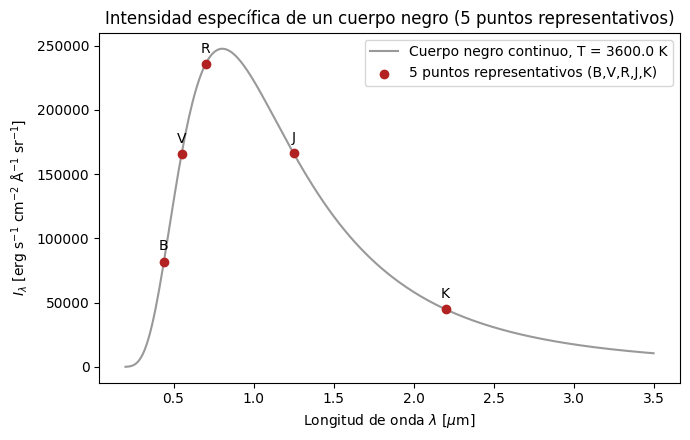

In [4]:
# Curva continua de referencia + los 5 puntos representativos
lam_continuo = np.linspace(0.2, 3.5, 300) * u.um
I_nu_continuo = cuerpo_negro(lam_continuo)
I_lambda_continuo = I_nu_continuo.to(u.erg / (u.s * u.cm**2 * u.AA * u.sr),
                                      equivalencies=u.spectral_density(lam_continuo))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lam_continuo.to(u.um), I_lambda_continuo, color="0.6", lw=1.5,
        label=f"Cuerpo negro continuo, T = {T_asumida}")
ax.scatter(longitudes_onda.to(u.um), I_lambda, color="firebrick", zorder=5,
           label="5 puntos representativos (B,V,R,J,K)")
for banda, lam, I in zip(bandas, longitudes_onda, I_lambda):
    ax.annotate(banda, (lam.value, I.value), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=10)
ax.set_xlabel(r"Longitud de onda $\lambda$ [$\mu$m]")
ax.set_ylabel(r"$I_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$ sr$^{-1}$]")
ax.set_title("Intensidad específica de un cuerpo negro (5 puntos representativos)")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Paso 3 — La distribución de brillo: disco uniforme

La estrella, vista desde la Tierra, no es un punto: subtiende un **tamaño angular** en el cielo. Vamos a representar su distribución de brillo como una imagen en 2D: un **disco uniforme** de intensidad $I$ constante dentro del disco, y cero afuera, dentro de un campo de visión (FOV) definido.

Antes de aplicarlo a Betelgeuse, exploremos **cómo cambia esta imagen con el tamaño angular del disco**, dejando la intensidad fija.


In [5]:
def disco_uniforme(I_valor, theta_diametro, fov, npix=201):
    # Construye la imagen (2D) de un disco uniforme.
    #
    # I_valor        : intensidad específica dentro del disco (Quantity, p.ej. erg/s/cm^2/AA/sr)
    # theta_diametro : diámetro angular del disco (Quantity de ángulo, p.ej. mas)
    # fov            : campo de visión total de la imagen (Quantity de ángulo)
    # npix           : número de píxeles por lado
    #
    # Retorna:
    #     imagen : arreglo (npix, npix) con unidades de I_valor
    #     eje    : eje angular de la imagen (Quantity), para graficar
    #     d_pix  : tamaño angular de un píxel (Quantity)
    eje = np.linspace(-fov / 2, fov / 2, npix)
    d_pix = eje[1] - eje[0]
    xx, yy = np.meshgrid(eje, eje)
    rr = np.sqrt(xx**2 + yy**2)
    dentro_del_disco = rr <= (theta_diametro / 2)

    imagen = np.zeros((npix, npix)) * I_valor.unit
    imagen[dentro_del_disco] = I_valor
    return imagen, eje, d_pix


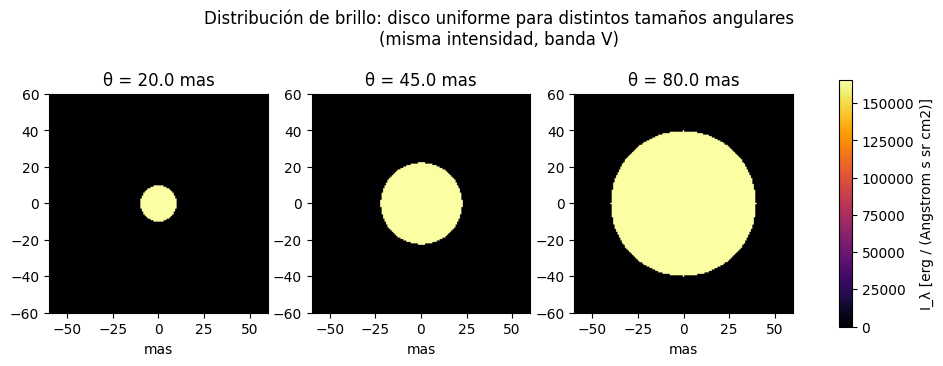

Noten que, aunque I es la misma en las tres imágenes, un disco angularmente más grande
subtiende más píxeles -> y por lo tanto, como veremos, un mayor flujo.


In [6]:
# Exploración: misma intensidad, distintos tamaños angulares
I_ejemplo = I_lambda[1]  # banda V, solo para ilustrar
fov_exploracion = 120 * u.mas
tamanos_angulares = [20, 45, 80] * u.mas

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, theta in zip(axes, tamanos_angulares):
    imagen, eje, d_pix = disco_uniforme(I_ejemplo, theta, fov_exploracion, npix=151)
    im = ax.imshow(imagen.value, origin="lower",
                    extent=[eje.value.min(), eje.value.max(), eje.value.min(), eje.value.max()],
                    cmap="inferno")
    ax.set_title(f"θ = {theta}")
    ax.set_xlabel("mas")
ax.figure.colorbar(im, ax=axes, shrink=0.8,
                    label=f"I_λ [{I_ejemplo.unit}]")
fig.suptitle("Distribución de brillo: disco uniforme para distintos tamaños angulares\n"
             "(misma intensidad, banda V)")
plt.show()

print("Noten que, aunque I es la misma en las tres imágenes, un disco angularmente más grande")
print("subtiende más píxeles -> y por lo tanto, como veremos, un mayor flujo.")


## 4. Paso 4 — El disco real de Betelgeuse y el flujo como suma de píxeles

Ahora usamos el **tamaño angular real** (aproximado) de Betelgeuse. Su diámetro angular ha sido medido por interferometría; usaremos un valor representativo de la literatura.

La idea clave: el **flujo** que mide un detector es la intensidad específica integrada sobre el ángulo sólido que subtiende la fuente. Para un disco uniforme (sin *limb darkening*) y en la aproximación de ángulo pequeño:

$$F_\lambda = \int I_\lambda \, d\Omega \;\approx\; I_\lambda \, \Omega_{disco}$$

Vamos a comprobar esto **de la forma más literal posible**: sumando el aporte de **cada píxel** de la imagen del disco.


In [7]:
# Diámetro angular de Betelgeuse (valor representativo de la literatura, p.ej. Haubois et al. 2009)
theta_betelgeuse = 45 * u.mas
fov_betelgeuse = 150 * u.mas
npix = 401

print(f"Diámetro angular adoptado para Betelgeuse: θ = {theta_betelgeuse}")


Diámetro angular adoptado para Betelgeuse: θ = 45.0 mas


In [8]:
def flujo_como_suma_de_pixeles(imagen, d_pix):
    # Suma el aporte de cada píxel: F = sum_pixeles( I_pixel * Omega_pixel ).
    # Usa la equivalencia dimensionless_angles() para convertir rad^2 -> sr.
    omega_pix = (d_pix.to(u.rad, equivalencies=u.dimensionless_angles())**2).to(
        u.sr, equivalencies=u.dimensionless_angles())
    flujo = np.sum(imagen) * omega_pix
    return flujo.to(u.erg / (u.s * u.cm**2 * u.AA))


def flujo_analitico_disco(I_valor, theta_diametro):
    # F = I * Omega_disco, con Omega_disco = pi*(theta/2)^2 (disco uniforme).
    theta_rad = theta_diametro.to(u.rad, equivalencies=u.dimensionless_angles())
    omega_disco = (np.pi * (theta_rad / 2)**2).to(u.sr, equivalencies=u.dimensionless_angles())
    return (I_valor * omega_disco).to(u.erg / (u.s * u.cm**2 * u.AA))


flujos_pixeles = []
flujos_analiticos = []

for banda, lam, I in zip(bandas, longitudes_onda, I_lambda):
    imagen, eje, d_pix = disco_uniforme(I, theta_betelgeuse, fov_betelgeuse, npix=npix)

    F_pixeles = flujo_como_suma_de_pixeles(imagen, d_pix)
    F_analitico = flujo_analitico_disco(I, theta_betelgeuse)

    flujos_pixeles.append(F_pixeles)
    flujos_analiticos.append(F_analitico)

    n_pix_disco = np.sum(imagen.value > 0)
    print(f"Banda {banda} (λ={lam}):")
    print(f"    píxeles dentro del disco : {n_pix_disco}")
    print(f"    F (suma de píxeles)      : {F_pixeles:.4e}")
    print(f"    F (fórmula analítica)    : {F_analitico:.4e}")
    print(f"    razón pixeles/analítico  : {(F_pixeles / F_analitico).decompose():.4f}\n")

flujos_pixeles = u.Quantity(flujos_pixeles)
flujos_analiticos = u.Quantity(flujos_analiticos)


Banda B (λ=0.44 um):
    píxeles dentro del disco : 11289
    F (suma de píxeles)      : 3.0606e-09 erg / (Angstrom s cm2)
    F (fórmula analítica)    : 3.0662e-09 erg / (Angstrom s cm2)
    razón pixeles/analítico  : 0.9982

Banda V (λ=0.55 um):
    píxeles dentro del disco : 11289
    F (suma de píxeles)      : 6.1725e-09 erg / (Angstrom s cm2)
    F (fórmula analítica)    : 6.1839e-09 erg / (Angstrom s cm2)
    razón pixeles/analítico  : 0.9982

Banda R (λ=0.7 um):
    píxeles dentro del disco : 11289
    F (suma de píxeles)      : 8.7937e-09 erg / (Angstrom s cm2)
    F (fórmula analítica)    : 8.8099e-09 erg / (Angstrom s cm2)
    razón pixeles/analítico  : 0.9982

Banda J (λ=1.25 um):
    píxeles dentro del disco : 11289
    F (suma de píxeles)      : 6.2059e-09 erg / (Angstrom s cm2)
    F (fórmula analítica)    : 6.2173e-09 erg / (Angstrom s cm2)
    razón pixeles/analítico  : 0.9982

Banda K (λ=2.2 um):
    píxeles dentro del disco : 11289
    F (suma de píxeles)      : 1.674

Como ven, la suma de píxeles converge al valor analítico $F_\lambda = I_\lambda\,\Omega_{disco}$ (la pequeña diferencia es el error de discretización por representar un círculo con una grilla cuadrada de píxeles; mientras más píxeles usemos, mejor será la aproximación).

Este es exactamente el mismo tipo de "suma de píxeles" que hace un detector real (CCD): cada píxel recibe un flujo, y el flujo total es la suma sobre todos los píxeles que cubren la fuente.


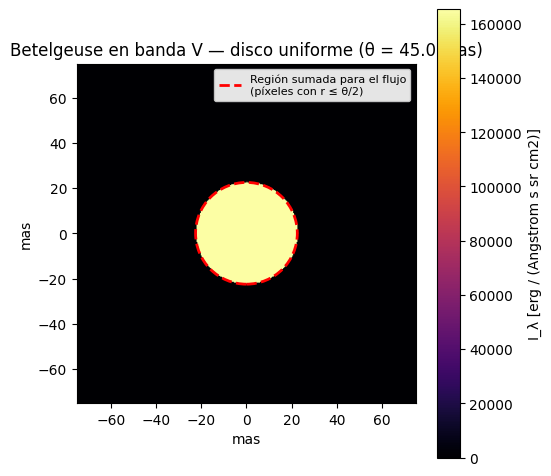

In [9]:
import matplotlib.patches as mpatches

imagen_V, eje_V, d_pix_V = disco_uniforme(I_lambda[1], theta_betelgeuse, fov_betelgeuse, npix=npix)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(imagen_V.value, origin="lower",
               extent=[eje_V.value.min(), eje_V.value.max(), eje_V.value.min(), eje_V.value.max()],
               cmap="inferno")

# Círculo rojo: marca exactamente la región (rr <= theta/2) sobre la que se
# suman los píxeles al calcular el flujo (ver flujo_como_suma_de_pixeles).
radio_disco = (theta_betelgeuse / 2).to(u.mas).value
circulo_suma = mpatches.Circle((0, 0), radio_disco, fill=False,
                                edgecolor="red", linewidth=2.0, linestyle="--", zorder=5)
ax.add_patch(circulo_suma)
ax.plot([], [], color="red", linestyle="--", linewidth=2.0,
        label="Región sumada para el flujo\n(píxeles con r ≤ θ/2)")

ax.set_xlabel("mas")
ax.set_ylabel("mas")
ax.set_title(f"Betelgeuse en banda V — disco uniforme (θ = {theta_betelgeuse})")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.colorbar(im, ax=ax, label=f"I_λ [{imagen_V.unit}]")
plt.tight_layout()
plt.show()


## 5. Paso 5 — Del flujo monocromático al flujo bolométrico: regla del trapecio

Tenemos $F_\lambda$ en 5 puntos ($B,V,R,J,K$). El **flujo bolométrico** (integrado sobre todas las longitudes de onda) es, en principio:

$$F_{bol} = \int_0^\infty F_\lambda \, d\lambda$$

Como solo tenemos 5 puntos (no una función continua), vamos a **aproximar esta integral con la regla del trapecio, calculada explícitamente**: entre cada par de puntos consecutivos $(\lambda_i, F_i)$ y $(\lambda_{i+1}, F_{i+1})$ formamos un trapecio de área

$$A_i = \frac{F_i + F_{i+1}}{2}\,(\lambda_{i+1} - \lambda_i)$$

y sumamos las áreas de los 4 trapecios (5 puntos -> 4 segmentos).


In [10]:
# Ordenamos los puntos por longitud de onda (por si acaso)
orden = np.argsort(longitudes_onda)
lam_ord = longitudes_onda[orden].to(u.AA)
F_ord = flujos_pixeles[orden]
bandas_ord = [bandas[i] for i in orden]

n = len(lam_ord)

# Regla del trapecio, explícita (segmento a segmento, sin scipy.integrate)
F_bol_trapecios = 0.0 * u.erg / (u.s * u.cm**2)
areas_trapecios = []
anchos = []
for i in range(n - 1):
    ancho_i = lam_ord[i + 1] - lam_ord[i]
    area_i = (0.5 * (F_ord[i] + F_ord[i + 1]) * ancho_i).to(u.erg / (u.s * u.cm**2))
    anchos.append(ancho_i)
    areas_trapecios.append(area_i)
    F_bol_trapecios += area_i
    print(f"Trapecio {bandas_ord[i]}-{bandas_ord[i+1]}: "
          f"Δλ={ancho_i:8.1f}  ->  área={area_i:.3e}")

print(f"\nFlujo bolométrico (regla del trapecio, 5 puntos): F_bol ≈ {F_bol_trapecios:.4e}")


Trapecio B-V: Δλ=  1100.0 Angstrom  ->  área=5.078e-06 erg / (s cm2)
Trapecio V-R: Δλ=  1500.0 Angstrom  ->  área=1.122e-05 erg / (s cm2)
Trapecio R-J: Δλ=  5500.0 Angstrom  ->  área=4.125e-05 erg / (s cm2)
Trapecio J-K: Δλ=  9500.0 Angstrom  ->  área=3.743e-05 erg / (s cm2)

Flujo bolométrico (regla del trapecio, 5 puntos): F_bol ≈ 9.4982e-05 erg / (s cm2)


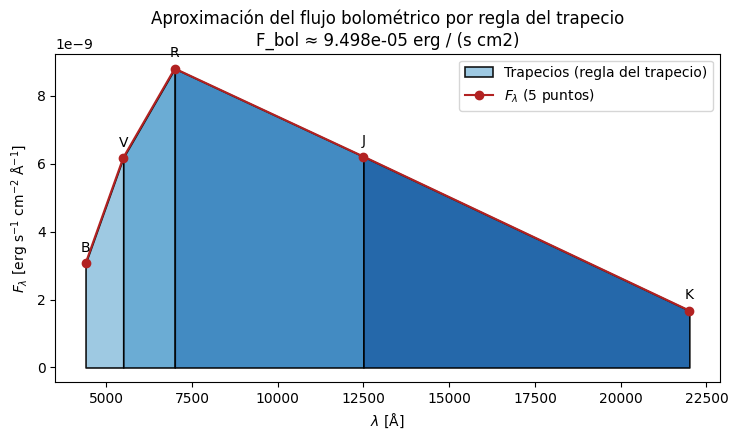

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Un tono de azul por trapecio (secuencial, claro -> oscuro) para que se vea
# cada segmento coloreado por separado bajo la curva.
colores = plt.cm.Blues(np.linspace(0.4, 0.85, n - 1))

for i in range(n - 1):
    x_seg = [lam_ord[i].value, lam_ord[i + 1].value]
    y_seg = [F_ord[i].value, F_ord[i + 1].value]
    etiqueta = "Trapecios (regla del trapecio)" if i == 0 else None
    ax.fill_between(x_seg, y_seg, color=colores[i], edgecolor="black",
                     linewidth=1.2, alpha=0.9, zorder=2, label=etiqueta)

ax.plot(lam_ord.value, F_ord.value, "o-", color="firebrick", zorder=3,
        label=r"$F_\lambda$ (5 puntos)")
for banda, lam, F in zip(bandas_ord, lam_ord, F_ord):
    ax.annotate(banda, (lam.value, F.value), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=10)

ax.set_xlabel(r"$\lambda$ [Å]")
ax.set_ylabel(r"$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title(f"Aproximación del flujo bolométrico por regla del trapecio\n"
             f"F_bol ≈ {F_bol_trapecios.value:.3e} {F_bol_trapecios.unit}")
ax.legend()
plt.tight_layout()
plt.show()


**Nota:** con solo 5 puntos, esta es una aproximación *gruesa* al flujo bolométrico real (nos perdemos, por ejemplo, todo el ultravioleta y el infrarrojo lejano, además de los extremos fuera de $[\lambda_B, \lambda_K]$, que el trapecio ni siquiera cubre). Aun así, para una estrella fría como Betelgeuse (que emite la mayor parte de su energía entre el óptico y el infrarrojo cercano), el resultado ya da el orden de magnitud correcto — lo verificamos más abajo comparando con la fórmula de Stefan-Boltzmann.


## 6. Paso 6 — Distancia (VizieR) y luminosidad en erg/s

Para pasar de **flujo** (lo que medimos) a **luminosidad** (lo que la estrella realmente emite) necesitamos la **distancia**:

$$L_{bol} = 4\pi d^2 F_{bol}$$

La distancia la obtenemos de la **paralaje**, que buscaremos en **VizieR** (por ejemplo, en el catálogo de Hipparcos `I/311/hip2`).


In [12]:
if HAY_ASTROQUERY:
    try:
        vizier = Vizier(columns=["Plx", "e_Plx"])
        resultado_vizier = vizier.query_object(nombre_estrella, catalog="I/311/hip2")
        print(resultado_vizier)
    except Exception as e:
        print(f"No se pudo consultar VizieR en este momento ({type(e).__name__}: {e}).")
        print("-> Revisen su conexión, o consulten directamente en https://vizier.cds.unistra.fr/")
else:
    print("astroquery no disponible: consulten manualmente en https://vizier.cds.unistra.fr/")

# TODO(alumno/a): reemplacen este valor por la paralaje que obtengan en VizieR.
# Se usa aquí un valor simple de referencia (Harper et al. 2008, revisión de Hipparcos)
# para poder seguir adelante con el cálculo mientras ustedes hacen su propia búsqueda.
paralaje_asumida = 5.95 * u.mas
print(f"\nParalaje asumida (PLACEHOLDER, a reemplazar): π = {paralaje_asumida}")


No se pudo consultar VizieR en este momento (ProxyError: HTTPSConnectionPool(host='vizier.cds.unistra.fr', port=443): Max retries exceeded with url: /viz-bin/votable (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))).
-> Revisen su conexión, o consulten directamente en https://vizier.cds.unistra.fr/

Paralaje asumida (PLACEHOLDER, a reemplazar): π = 5.95 mas


In [13]:
distancia = paralaje_asumida.to(u.pc, equivalencies=u.parallax())
print(f"Distancia:  d = {distancia:.2f} = {distancia.to(u.lyr):.2f}")

L_bol = (4 * np.pi * distancia.to(u.cm)**2 * F_bol_trapecios).to(u.erg / u.s)
print(f"\nLuminosidad bolométrica (a partir de la regla del trapecio de 5 puntos):")
print(f"    L_bol = {L_bol:.4e}")
print(f"    L_bol = {(L_bol / const.L_sun).decompose():.1f} L_sun")


Distancia:  d = 168.07 pc = 548.16 lyr

Luminosidad bolométrica (a partir de la regla del trapecio de 5 puntos):
    L_bol = 3.2101e+38 erg / s
    L_bol = 83858.4 L_sun


### ¿Calzan las unidades? Verificación dimensional explícita

$L_{bol} = 4\pi d^2 F_{bol}$ debería dar **erg/s** (potencia). Veamos por qué, sin dejar que `astropy` "arregle" nada por detrás con el `.to()`: miremos la unidad **antes** de forzar la conversión, y descompongámosla en unidades base cgs.


In [14]:
# 1) ¿Qué unidad tiene el producto ANTES de pedirle a astropy que convierta a erg/s?
producto_sin_convertir = 4 * np.pi * distancia.to(u.cm)**2 * F_bol_trapecios
print(f"Unidad de (4π d² F_bol) tal cual sale, sin pedir conversión: {producto_sin_convertir.unit}")
print(f"Tipo físico de esa unidad: {producto_sin_convertir.unit.physical_type}")

# 2) Descomposición en unidades base del sistema cgs (g, cm, s)
print(f"\nDescompuesto en unidades base (cgs): {producto_sin_convertir.decompose(u.cgs.bases)}")

# 3) A mano: [d²] = cm²,  [F_bol] = erg/(s·cm²)  =>  [d²][F_bol] = cm² · erg/(s·cm²) = erg/s
print("\nA mano:")
print(f"    [d²]      = {(distancia.to(u.cm)**2).unit}")
print(f"    [F_bol]   = {F_bol_trapecios.unit}")
print(f"    [d²·F_bol] = cm² · erg/(s·cm²)  ->  se cancela cm²  ->  erg/s")

# 4) erg en sí mismo es una unidad compuesta: erg = g·cm²/s²  ->  erg/s = g·cm²/s³
print(f"\nY erg/s equivale, en unidades base, a: {(u.erg/u.s).decompose(u.cgs.bases)}")
print(f"physical_type de erg/s: {(u.erg/u.s).physical_type}  (= potencia / luminosidad)")


Unidad de (4π d² F_bol) tal cual sale, sin pedir conversión: erg / s
Tipo físico de esa unidad: power/radiant flux

Descompuesto en unidades base (cgs): 3.2100981952017855e+38 cm2 g / s3

A mano:
    [d²]      = cm2
    [F_bol]   = erg / (s cm2)
    [d²·F_bol] = cm² · erg/(s·cm²)  ->  se cancela cm²  ->  erg/s

Y erg/s equivale, en unidades base, a: cm2 g / s3
physical_type de erg/s: power/radiant flux  (= potencia / luminosidad)


Como ven, el `cm²` de la distancia se cancela exactamente con el `cm²` que estaba en el denominador de $F_{bol}$ (erg s$^{-1}$ cm$^{-2}$), dejando **erg/s** de forma natural — **no** es que `astropy` haya forzado una conversión incorrecta con `.to()`; el resultado ya "nace" con esas unidades. Si en algún momento las unidades no cancelaran así, `astropy` habría lanzado un `UnitConversionError` al pedir `.to(u.erg/u.s)`, así que el hecho de que no haya reclamado es, en sí mismo, una confirmación.


### Chequeo de sanidad: comparación con Stefan-Boltzmann

Como comparación (no reemplaza la regla del trapecio anterior, que es la que pide el ejercicio), podemos calcular el flujo bolométrico **exacto** de un cuerpo negro con la ley de Stefan-Boltzmann, $F_{bol} = \sigma T^4 \,(\theta/2)^2$, y ver qué tan cerca estuvo nuestra aproximación de 5 puntos.


In [15]:
theta_rad = theta_betelgeuse.to(u.rad, equivalencies=u.dimensionless_angles())
F_bol_stefan_boltzmann = (const.sigma_sb * T_asumida**4 * (theta_rad / 2)**2).to(
    u.erg / (u.s * u.cm**2), equivalencies=u.dimensionless_angles())

L_bol_stefan_boltzmann = (4 * np.pi * distancia.to(u.cm)**2 * F_bol_stefan_boltzmann).to(u.erg / u.s)

print(f"F_bol (trapecio, 5 puntos)     : {F_bol_trapecios:.4e}")
print(f"F_bol (Stefan-Boltzmann, exacto): {F_bol_stefan_boltzmann:.4e}")
print(f"razón trapecio/exacto           : {(F_bol_trapecios / F_bol_stefan_boltzmann).decompose():.3f}\n")

print(f"L_bol (trapecio, 5 puntos)      : {L_bol:.3e}  =  {(L_bol/const.L_sun).decompose():.0f} L_sun")
print(f"L_bol (Stefan-Boltzmann, exacto) : {L_bol_stefan_boltzmann:.3e}  =  {(L_bol_stefan_boltzmann/const.L_sun).decompose():.0f} L_sun")
print("\n(Valor de referencia en la literatura para Betelgeuse: L ~ 1-1.5 x 10^5 L_sun)")


F_bol (trapecio, 5 puntos)     : 9.4982e-05 erg / (s cm2)
F_bol (Stefan-Boltzmann, exacto): 1.1333e-04 erg / (s cm2)
razón trapecio/exacto           : 0.838

L_bol (trapecio, 5 puntos)      : 3.210e+38 erg / s  =  83858 L_sun
L_bol (Stefan-Boltzmann, exacto) : 3.830e+38 erg / s  =  100056 L_sun

(Valor de referencia en la literatura para Betelgeuse: L ~ 1-1.5 x 10^5 L_sun)


## 7. Para pensar / entregar

1. Reemplacen `T_asumida` y `paralaje_asumida` por los valores que ustedes obtengan directamente de SIMBAD y VizieR. ¿Cuánto cambia $L_{bol}$?
2. ¿Por qué la suma de píxeles no da **exactamente** igual al valor analítico $I\,\Omega_{disco}$? ¿Qué pasa si aumentan `npix`?
3. La regla del trapecio con solo 5 puntos, ¿sobreestima o subestima el flujo bolométrico real? ¿Por qué (piensen en qué rangos de $\lambda$ nos estamos perdiendo)?
4. Si Betelgeuse fuera el doble de grande en diámetro angular (mismo $T$), ¿cómo cambiaría el flujo? ¿Y si estuviera al doble de distancia (mismo diámetro angular)?
5. Todo este notebook evitó a propósito el sistema de magnitudes. ¿Cómo convertirían $F_{bol}$ en una magnitud aparente, y $L_{bol}$ en una magnitud absoluta? (Lo veremos en la próxima clase.)
